## Objetivo ##



<span style="color: black; font-family: Arial; font-size: 20px;">
O objetivo deste projeto é analisar os fatores que influenciam a rotatividade de clientes da operadora de comunicações Interconnect, com base em dados contratuais, comportamentais e de serviços utilizados. A empresa busca entender quais perfis de clientes estão mais propensos a cancelar seus contratos, a fim de implementar estratégias preventivas, como ofertas personalizadas, planos alternativos e ações de fidelização.



## Carregando todas as bibliotecas ##

In [4]:
from scipy import stats as st
from statsmodels.stats.proportion import proportions_ztest
import numpy as np
import scipy.stats as stats
from scipy.stats import ttest_ind, levene
import pandas as pd
from math import factorial
from plotly import graph_objects as go
from datetime import datetime
import math
import matplotlib.ticker as mtick
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.express as px

## Visão geral dos dados ##

In [6]:
# Carregando o dataframe 'contract'
contract = pd.read_csv(r"C:\Users\pedro\Documents\Dataframes projetos\interconnect-churn-analysis\contract.csv")
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   BeginDate         7043 non-null   object 
 2   EndDate           7043 non-null   object 
 3   Type              7043 non-null   object 
 4   PaperlessBilling  7043 non-null   object 
 5   PaymentMethod     7043 non-null   object 
 6   MonthlyCharges    7043 non-null   float64
 7   TotalCharges      7043 non-null   object 
dtypes: float64(1), object(7)
memory usage: 440.3+ KB


In [7]:
# Carregando o dataframe 'personal'
personal = pd.read_csv(r"C:\Users\pedro\Documents\Dataframes projetos\interconnect-churn-analysis\personal.csv")
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     7043 non-null   object
 1   gender         7043 non-null   object
 2   SeniorCitizen  7043 non-null   int64 
 3   Partner        7043 non-null   object
 4   Dependents     7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


In [8]:
# Carregando o dataframe 'internet'
internet = pd.read_csv(r"C:\Users\pedro\Documents\Dataframes projetos\interconnect-churn-analysis\internet.csv")
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   customerID        5517 non-null   object
 1   InternetService   5517 non-null   object
 2   OnlineSecurity    5517 non-null   object
 3   OnlineBackup      5517 non-null   object
 4   DeviceProtection  5517 non-null   object
 5   TechSupport       5517 non-null   object
 6   StreamingTV       5517 non-null   object
 7   StreamingMovies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


In [9]:
# Carregando o dataframe 'phone'
phone = pd.read_csv(r"C:\Users\pedro\Documents\Dataframes projetos\interconnect-churn-analysis\phone.csv")
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   customerID     6361 non-null   object
 1   MultipleLines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


## Pré-processamento de dados

### DataFrame `contract`

In [12]:
contract.head()

,customerID,BeginDate,EndDate,Type,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,7590-VHVEG,2020-01-01,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,5575-GNVDE,2017-04-01,No,One year,No,Mailed check,56.95,1889.5
2,3668-QPYBK,2019-10-01,2019-12-01 00:00:00,Month-to-month,Yes,Mailed check,53.85,108.15
3,7795-CFOCW,2016-05-01,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,9237-HQITU,2019-09-01,2019-11-01 00:00:00,Month-to-month,Yes,Electronic check,70.70,151.65


In [13]:
# Verificando se há valores duplicados
print(contract.duplicated().sum())

0


In [14]:
# Verificando os valores ausentes
print(contract.isna().sum())

customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [15]:
# Percorrendo os cabeçalhos e convertendo tudo em minúsculos
new_col_names=[]
for old_name in contract.columns:
    name_lowered=old_name.lower()
    new_col_names.append(name_lowered)
contract.columns=new_col_names
print(contract.columns)

Index(['customerid', 'begindate', 'enddate', 'type', 'paperlessbilling',
       'paymentmethod', 'monthlycharges', 'totalcharges'],
      dtype='object')


In [16]:
# Incluindo um sepador no nome das colunas
columns_new = {'customerid': 'customer_id',
               'begindate': 'begin_date',
               'enddate': 'end_date',
               'paperlessbilling': 'paperless_billing',
               'paymentmethod': 'payment_method',
               'monthlycharges': 'monthly_charges',
               'totalcharges': 'total_charges'}
contract.rename(columns=columns_new, inplace=True)
print(contract.columns)

Index(['customer_id', 'begin_date', 'end_date', 'type', 'paperless_billing',
       'payment_method', 'monthly_charges', 'total_charges'],
      dtype='object')


In [17]:
# Convertendo as colunas 'begin_date' e 'end_date' para datetime
contract['begin_date'] = pd.to_datetime(contract['begin_date'])
contract['end_date'] = pd.to_datetime(contract['end_date'], errors='coerce')

C:\Users\pedro\AppData\Local\Temp\ipykernel_28496\2079930861.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  contract['end_date'] = pd.to_datetime(contract['end_date'], errors='coerce')


In [18]:
# Convertendo a coluna 'total_charges' para float64
contract['total_charges'] = pd.to_numeric(contract['total_charges'], errors='coerce')

In [19]:
contract.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_id        7043 non-null   object        
 1   begin_date         7043 non-null   datetime64[ns]
 2   end_date           1869 non-null   datetime64[ns]
 3   type               7043 non-null   object        
 4   paperless_billing  7043 non-null   object        
 5   payment_method     7043 non-null   object        
 6   monthly_charges    7043 non-null   float64       
 7   total_charges      7032 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(4)
memory usage: 440.3+ KB


### DataFrame `personal`

In [21]:
personal.head()

,customerID,gender,SeniorCitizen,Partner,Dependents
0,7590-VHVEG,Female,0,Yes,No
1,5575-GNVDE,Male,0,No,No
2,3668-QPYBK,Male,0,No,No
3,7795-CFOCW,Male,0,No,No
4,9237-HQITU,Female,0,No,No


In [22]:
# Verificando se há valores duplicados
print(personal.duplicated().sum())

0


In [23]:
# Verificando os valores ausentes
print(personal.isna().sum())

customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64


In [24]:
# Percorrendo os cabeçalhos e convertendo tudo em minúsculos
new_col_names=[]
for old_name in personal.columns:
    name_lowered=old_name.lower()
    new_col_names.append(name_lowered)
personal.columns=new_col_names
print(personal.columns)

Index(['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents'], dtype='object')


In [25]:
# Incluindo um sepador no nome das colunas
columns_new = {'customerid': 'customer_id', 'seniorcitizen': 'senior_citizen'}
personal.rename(columns=columns_new, inplace=True)
print(personal.columns)

Index(['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents'], dtype='object')


In [26]:
personal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     7043 non-null   object
 1   gender          7043 non-null   object
 2   senior_citizen  7043 non-null   int64 
 3   partner         7043 non-null   object
 4   dependents      7043 non-null   object
dtypes: int64(1), object(4)
memory usage: 275.2+ KB


### DataFrame `internet`

In [28]:
internet.head()

,customerID,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,7590-VHVEG,DSL,No,Yes,No,No,No,No
1,5575-GNVDE,DSL,Yes,No,Yes,No,No,No
2,3668-QPYBK,DSL,Yes,Yes,No,No,No,No
3,7795-CFOCW,DSL,Yes,No,Yes,Yes,No,No
4,9237-HQITU,Fiber optic,No,No,No,No,No,No


In [29]:
# Verificando se há valores duplicados
print(internet.duplicated().sum())

0


In [30]:
# Verificando os valores ausentes
print(internet.isna().sum())

customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64


In [31]:
# Percorrendo os cabeçalhos e convertendo tudo em minúsculos
new_col_names=[]
for old_name in internet.columns:
    name_lowered=old_name.lower()
    new_col_names.append(name_lowered)
internet.columns=new_col_names
print(internet.columns)

Index(['customerid', 'internetservice', 'onlinesecurity', 'onlinebackup',
       'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies'],
      dtype='object')


In [32]:
# Incluindo um sepador no nome das colunas
columns_new = {'customerid': 'customer_id',
               'internetservice': 'internet_service',
               'onlinesecurity': 'online_security',
               'onlinebackup': 'online_backup',
               'deviceprotection': 'device_protection',
               'techsupport': 'tech_support',
               'streamingtv': 'streaming_tv',
               'streamingmovies': 'streaming_movies'}
internet.rename(columns=columns_new, inplace=True)
print(internet.columns)

Index(['customer_id', 'internet_service', 'online_security', 'online_backup',
       'device_protection', 'tech_support', 'streaming_tv',
       'streaming_movies'],
      dtype='object')


In [33]:
internet.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5517 entries, 0 to 5516
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   customer_id        5517 non-null   object
 1   internet_service   5517 non-null   object
 2   online_security    5517 non-null   object
 3   online_backup      5517 non-null   object
 4   device_protection  5517 non-null   object
 5   tech_support       5517 non-null   object
 6   streaming_tv       5517 non-null   object
 7   streaming_movies   5517 non-null   object
dtypes: object(8)
memory usage: 344.9+ KB


### DataFrame `phone`

In [35]:
phone.head()

,customerID,MultipleLines
0,5575-GNVDE,No
1,3668-QPYBK,No
2,9237-HQITU,No
3,9305-CDSKC,Yes
4,1452-KIOVK,Yes


In [36]:
# Verificando se há valores duplicados
print(phone.duplicated().sum())

0


In [37]:
# Verificando os valores ausentes
print(phone.isna().sum())

customerID       0
MultipleLines    0
dtype: int64


In [38]:
# Percorrendo os cabeçalhos e convertendo tudo em minúsculos
new_col_names=[]
for old_name in phone.columns:
    name_lowered=old_name.lower()
    new_col_names.append(name_lowered)
phone.columns=new_col_names
print(phone.columns)

Index(['customerid', 'multiplelines'], dtype='object')


In [39]:
# Incluindo um sepador no nome das colunas
columns_new = {'customerid': 'customer_id', 'multiplelines': 'multiple_lines'}
phone.rename(columns=columns_new, inplace=True)
print(phone.columns)

Index(['customer_id', 'multiple_lines'], dtype='object')


In [40]:
phone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6361 entries, 0 to 6360
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     6361 non-null   object
 1   multiple_lines  6361 non-null   object
dtypes: object(2)
memory usage: 99.5+ KB


## Análise exploratória de dados

In [42]:
# Mesclando todas as informações da empresa sobre os clientes
id_merged = contract.merge(personal, on='customer_id')\
             .merge(internet, on='customer_id')\
             .merge(phone, on='customer_id')
id_merged.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,partner,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines
0,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,Male,0,No,No,DSL,Yes,No,Yes,No,No,No,No
1,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,No,No,DSL,Yes,Yes,No,No,No,No,No
2,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,No,No,Fiber optic,No,No,No,No,No,No,No
3,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Female,0,No,No,Fiber optic,No,No,Yes,No,Yes,Yes,Yes
4,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Male,0,No,Yes,Fiber optic,No,Yes,No,No,Yes,No,Yes


<span style="color: black; font-family: Arial; font-size: 20px;">
Como não há uma coluna explícita para a rotatividade (churn), ela pode ser derivada da coluna 'end_date' indicando se o cliente encerrou o contrato antes da data da análise (01/02/2020).

In [44]:
# Definindo data de análise
analysis_date = pd.to_datetime('2020-02-01')

# Se a data de término do contrato for anterior a 01/02/2020, quer dizer que o cliente saiu
id_merged['churn'] = id_merged['end_date'] < analysis_date

# Conferir distribuição
id_merged['churn'].value_counts(normalize=True)

churn
False    0.671975
True     0.328025
Name: proportion, dtype: float64

In [45]:
id_merged.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,...,dependents,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,churn
0,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,Male,0,...,No,DSL,Yes,No,Yes,No,No,No,No,False
1,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,No,DSL,Yes,Yes,No,No,No,No,No,True
2,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,No,Fiber optic,No,No,No,No,No,No,No,True
3,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Female,0,...,No,Fiber optic,No,No,Yes,No,Yes,Yes,Yes,True
4,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Male,0,...,Yes,Fiber optic,No,Yes,No,No,Yes,No,Yes,False


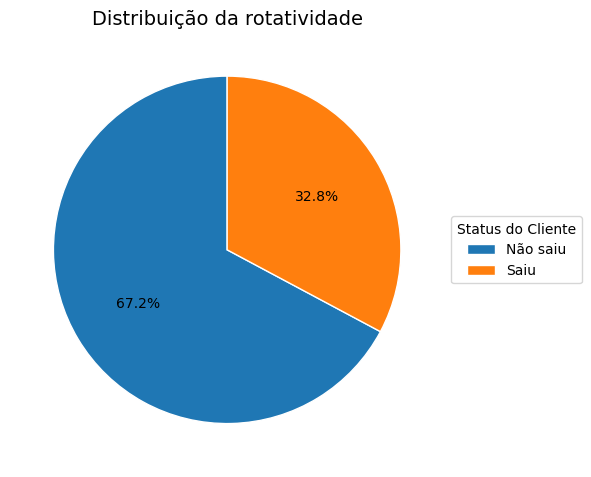

In [46]:

# Contando a proporção
churn_dist = id_merged['churn'].value_counts(normalize=True)

# Criando gráfico de pizza
labels1 = churn_dist.index.map({True: 'Saiu', False: 'Não saiu'})
plt.figure(figsize=(6, 6))
plt.pie(churn_dist, labels=None, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'white'})
plt.title('Distribuição da rotatividade', fontsize=14)
plt.legend(labels1, title="Status do Cliente", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()




<span style="color: black; font-family: Arial; font-size: 20px;">
Se a data de término do contrato do cliente for anterior a 01/02/2020, quer dizer que ele saiu. Se a data for posterior a 01/02/2020, quer dizer que o cliente não saiu.



## Tipo de Contrato vs Rotatividade

C:\Users\pedro\AppData\Local\Temp\ipykernel_28496\3773712297.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_contract, x='type', y='churn_rate', palette='Set2')


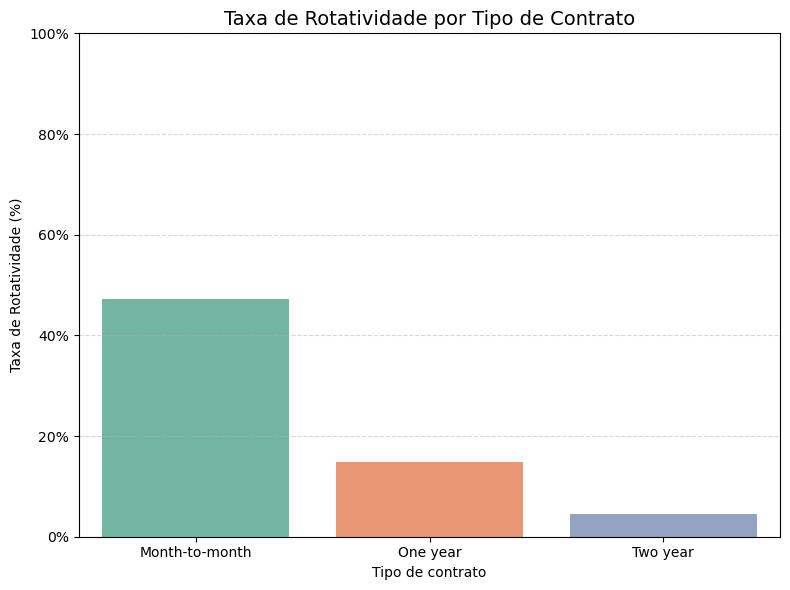

In [49]:
# Calculando a taxa de churn por tipo de contrato
churn_by_contract = id_merged.groupby('type')['churn'].mean().reset_index()
churn_by_contract.rename(columns={'churn': 'churn_rate'}, inplace=True)

# Plotando gráfico
plt.figure(figsize=(8, 6))
sns.barplot(data=churn_by_contract, x='type', y='churn_rate', hue='type', palette='Set2')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Taxa de Rotatividade por Tipo de Contrato', fontsize=14)
plt.xlabel('Tipo de contrato')
plt.ylabel('Taxa de Rotatividade (%)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<span style="color: black; font-family: Arial; font-size: 20px;">
Clientes com contratos menores têm mais tendência a sair. O contrato de um mês tem uma taxa de rotatividade de mais de 40%.

## Crescimento de Receita vs Rotatividade


<span style="color: blue; font-family: Arial; font-size: 20px;">
Calcular crescimento de receita por cliente. Visualizar relação com a rotatividade.


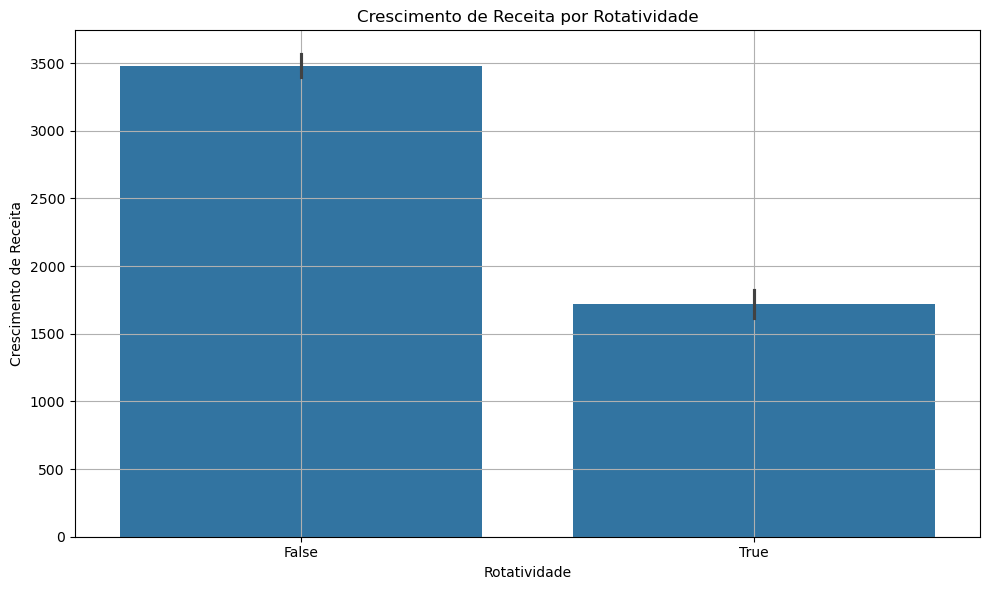

In [53]:
# Visualizando o crescimento da receita por cliente e sua relação com a rotatividade
plt.figure(figsize=(10, 6))
sns.barplot(data=id_merged, x='churn', y='total_charges')
plt.title('Crescimento de Receita por Rotatividade')
plt.xlabel('Rotatividade')
plt.ylabel('Crescimento de Receita')
plt.grid(True)
plt.tight_layout()
plt.show()


<span style="color: black; font-family: Arial; font-size: 20px;">
Clientes que não saíram tiveram um maior crescimento de receita do que os clientes que saíram.


C:\Users\pedro\AppData\Local\Temp\ipykernel_28496\4172832315.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_churn = id_merged.groupby('revenue_group')['churn'].mean()


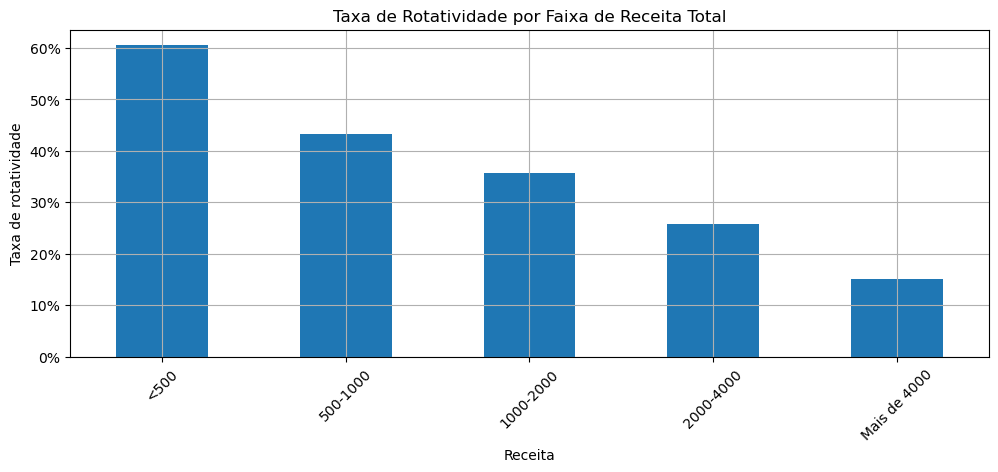

In [55]:
# Classificando as receitas em faixas
bins = [0, 500, 1000, 2000, 4000, id_merged['total_charges'].max()]
labels = ['<500', '500-1000', '1000-2000', '2000-4000', 'Mais de 4000']
id_merged['revenue_group'] = pd.cut(id_merged['total_charges'], bins=bins, labels=labels)

# Proporção de churn por grupo
revenue_churn = id_merged.groupby('revenue_group')['churn'].mean()

# Gráfico
revenue_churn.plot(kind='bar', figsize=(10,5), title='Taxa de Rotatividade por Faixa de Receita Total')
plt.ylabel('Taxa de rotatividade')
plt.xlabel('Receita')
plt.grid(True)
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.show()

<span style="color: black; font-family: Arial; font-size: 20px;">
Clientes que gastam menos de $500 têm uma taxa de rotatividade de 60%

## Frequência de pagamento vs rotatividade


<span style="color: blue; font-family: Arial; font-size: 20px;">
Calcular frequência média de pagamentos


In [59]:
id_merged['months_active'] = id_merged['total_charges'] / id_merged['monthly_charges']
id_merged.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,...,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,multiple_lines,churn,revenue_group,months_active
0,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,Male,0,...,Yes,No,Yes,No,No,No,No,False,1000-2000,33.178227
1,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,Yes,Yes,No,No,No,No,No,True,<500,2.008357
2,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,No,No,No,No,No,No,No,True,<500,2.144979
3,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Female,0,...,No,No,Yes,No,Yes,Yes,Yes,True,500-1000,8.233818
4,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Male,0,...,No,Yes,No,No,Yes,No,Yes,False,1000-2000,21.878788





<span style="color: blue; font-family: Arial; font-size: 20px;">
Agrupar por faixa de tempo de permanência




In [61]:
# Criando faixas de tempo de permanência
bins = [0, 6, 12, 24, 36, 60]
labels = ['Até 6 meses', '6-12 meses', '12-24 meses', '24-36 meses', 'Mais de 36 meses']
id_merged['payment_freq_group'] = pd.cut(id_merged['months_active'], bins=bins, labels=labels)

C:\Users\pedro\AppData\Local\Temp\ipykernel_28496\590458663.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  freq_churn = id_merged.groupby('payment_freq_group')['churn'].value_counts(normalize=True).unstack().fillna(0)


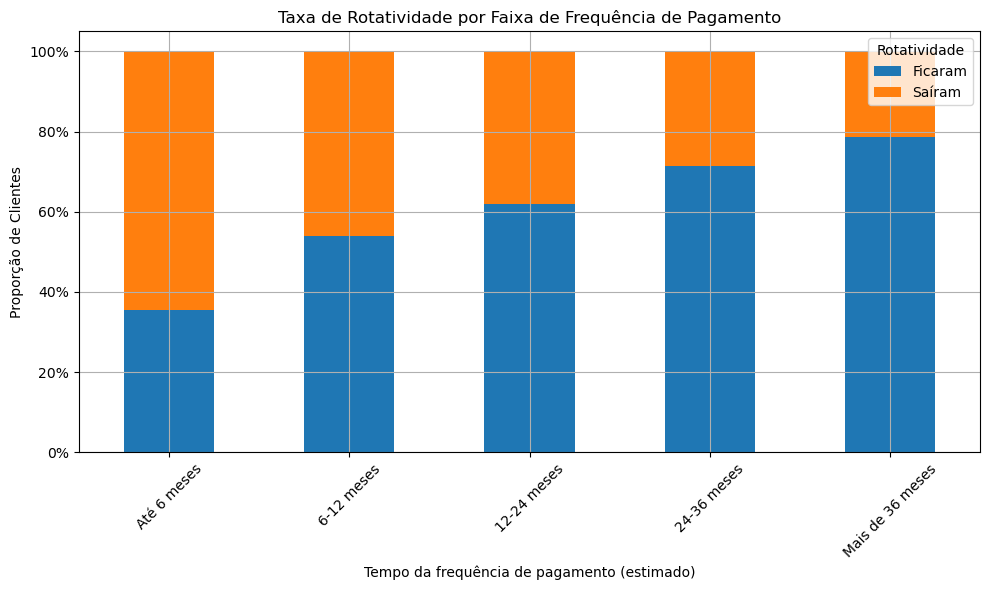

In [62]:


# Agrupando por frequencia de pagamento e rotatividade
freq_churn = id_merged.groupby('payment_freq_group')['churn'].value_counts(normalize=True).unstack().fillna(0)

# Criando um gráfico para visualizar a distribuição
freq_churn.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Taxa de Rotatividade por Faixa de Frequência de Pagamento')
plt.xlabel('Tempo da frequência de pagamento (estimado)')
plt.ylabel('Proporção de Clientes')
plt.legend(['Ficaram', 'Saíram'], title='Rotatividade')
plt.grid(True)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




<span style="color: black; font-family: Arial; font-size: 20px;">
Quanto mais tempo os clientes fazem pagamentos a empresa, mais eles tendem a permanecer nela. Clientes pagantes a mais de 3 anos são quase 80% dos que ainda ficam na empresa.



<span style="color: blue; font-family: Arial; font-size: 20px;">
Frequência média de pagamento por tipo de contrato



In [65]:

contract_stats = id_merged.groupby('type').agg({
    'months_active': 'mean',
    'churn': 'mean',
    'customer_id': 'count'
}).rename(columns={
    'months_active': 'avg_months_active',
    'churn': 'churn_rate',
    'customer_id': 'total_customers'
}).sort_values('avg_months_active', ascending=False)

contract_stats.head()


,avg_months_active,churn_rate,total_customers
type,,,
Two year,62.926134,0.044643,896
One year,47.144606,0.148340,964
Month-to-month,19.519436,0.471597,2975


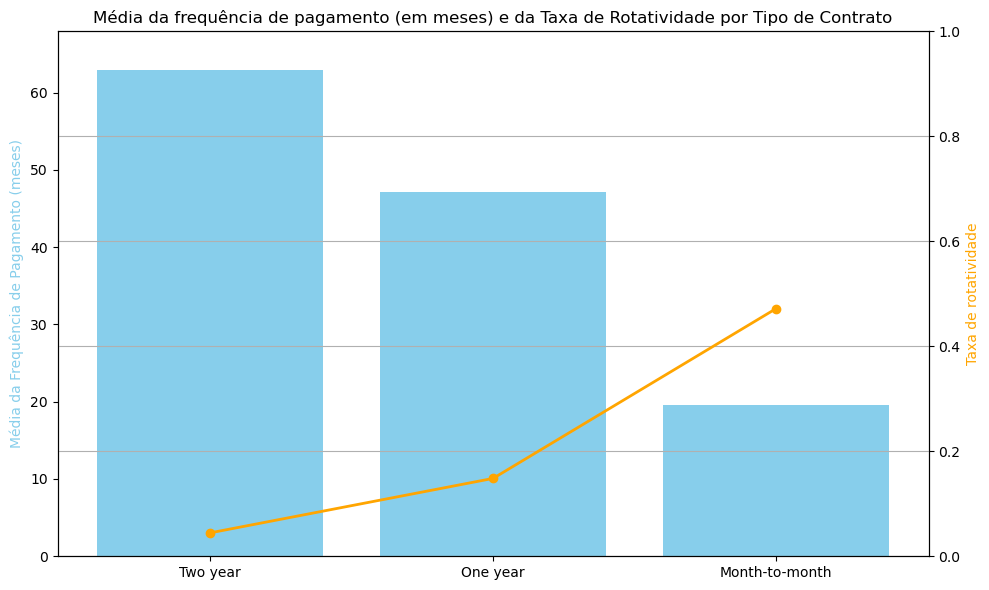

In [66]:

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.bar(contract_stats.index, contract_stats['avg_months_active'], color='skyblue', label='Média de meses ativos')
ax1.set_ylabel('Média da Frequência de Pagamento (meses)', color='skyblue')
ax1.set_ylim(0, contract_stats['avg_months_active'].max() + 5)
ax2 = ax1.twinx()
ax2.plot(contract_stats.index, contract_stats['churn_rate'], color='orange', marker='o', linewidth=2, label='Taxa de Churn')
ax2.set_ylabel('Taxa de rotatividade', color='orange')
ax2.set_ylim(0, 1)
plt.title('Média da frequência de pagamento (em meses) e da Taxa de Rotatividade por Tipo de Contrato')
fig.tight_layout()
plt.grid(True)
plt.show()




<span style="color: black; font-family: Arial; font-size: 20px;">
Clientes com uma maior média de frequência de pagamentos são os que tem contratos de 2 anos. A taxa de rotatividade cresce conforme os contratos dos clientes são menores.



## Tipo de serviço de internet vs Rotatividade


<span style="color: blue; font-family: Arial; font-size: 20px;">
Verificar se o tipo de internet influencia na rotatividade


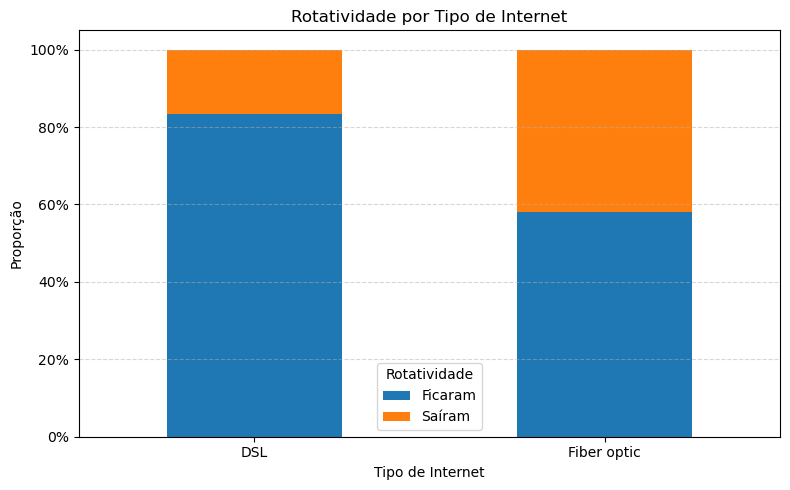

In [70]:

# Agrupando por rotatividade por tipo de internet e construindo um gráfico representativo
churn_by_internet = id_merged.groupby('internet_service')['churn'].value_counts(normalize=True).unstack()
churn_by_internet.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Rotatividade por Tipo de Internet')
plt.ylabel('Proporção')
plt.xlabel('Tipo de Internet')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(['Ficaram', 'Saíram'], title='Rotatividade')
plt.tight_layout()
plt.show()





<span style="color: black; font-family: Arial; font-size: 20px;">
Clientes que usaram Fibra Ótica saíram mais da empresa do que aqueles que usaram DSL.



## Faixa etária vs Rotatividade

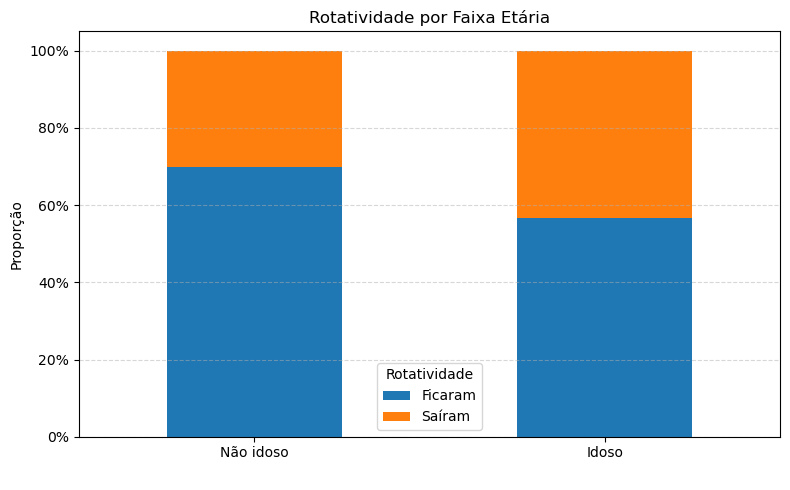

In [73]:

# Agrupando rotatividade por faixa etária e construindo um gráfico representativo
id_merged.groupby('senior_citizen')['churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', stacked=True, figsize=(8,5), title='Rotatividade por Faixa Etária'
)
plt.ylabel('Proporção')
plt.xlabel(' ')
plt.xticks([0, 1], ['Não idoso', 'Idoso'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Ficaram', 'Saíram'], title='Rotatividade')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()



<span style="color: black; font-family: Arial; font-size: 20px;">
Clientes idosos tendem a sair mais do que clientes que não são idosos.


## Multiplas linhas telefônicas vs Rotatividade

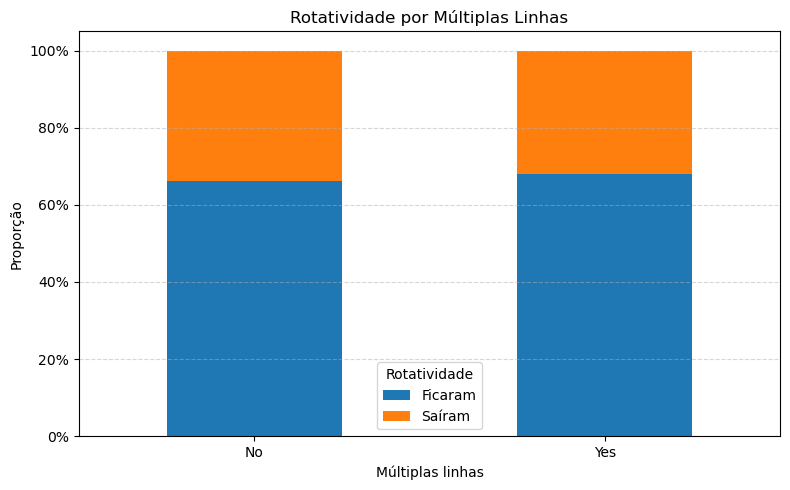

In [76]:
# Agrupando rotatividade por clientes que tem multiplas linhas e construindo um gráfico representativo
id_merged.groupby('multiple_lines')['churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', stacked=True, figsize=(8,5), title='Rotatividade por Múltiplas Linhas'
)
plt.ylabel('Proporção')
plt.xlabel('Múltiplas linhas')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Ficaram', 'Saíram'], title='Rotatividade')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()



<span style="color: black; font-family: Arial; font-size: 20px;">
A proporção de clientes com ou sem múltiplas linhas não impactaram significamente na rotatividade.




## Clientes que possuem parceiros vs Rotatividade

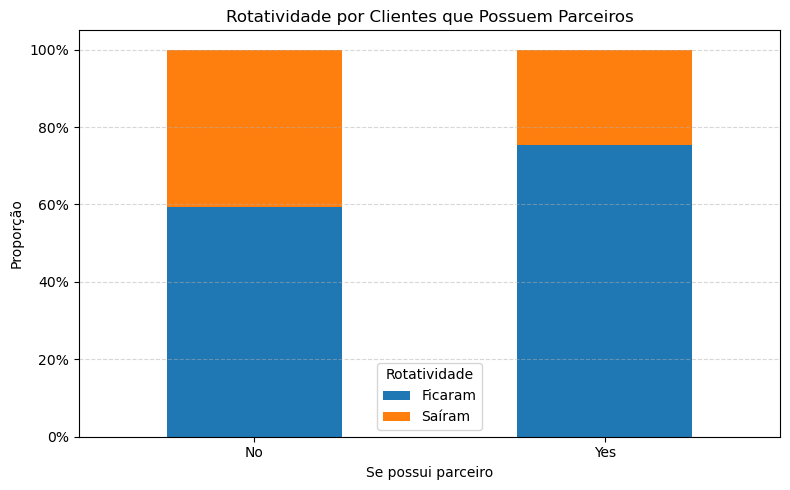

In [79]:

# Agrupando rotatividade por clientes que possuem parceiros e construindo um gráfico representativo
id_merged.groupby('partner')['churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', stacked=True, figsize=(8,5), title='Rotatividade por Clientes que Possuem Parceiros'
)
plt.ylabel('Proporção')
plt.xlabel('Se possui parceiro')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Ficaram', 'Saíram'], title='Rotatividade')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()



<span style="color: black; font-family: Arial; font-size: 20px;">
Clientes que possuem parceiros tem mais tendência a ficar na empresa do que aqueles que não possuem.


## Clientes que possuem dependentes vs Rotatividade

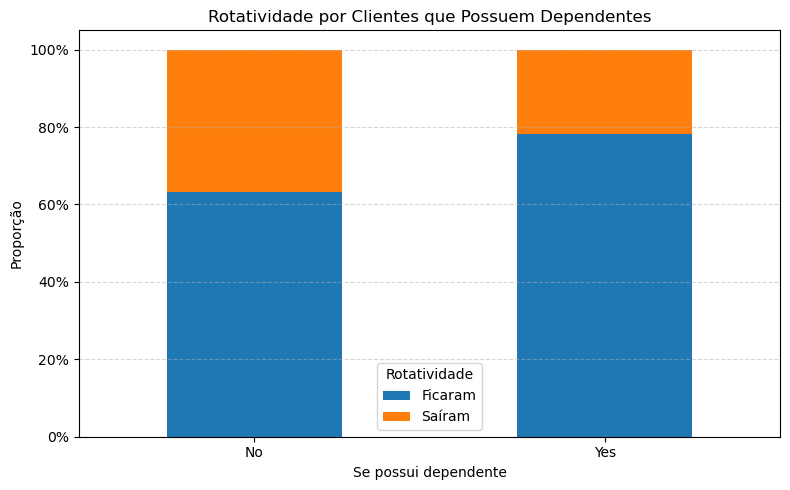

In [82]:
# Agrupando rotatividade por clientes que possuem dependentes e construindo um gráfico representativo
id_merged.groupby('dependents')['churn'].value_counts(normalize=True).unstack().plot(
    kind='bar', stacked=True, figsize=(8,5), title='Rotatividade por Clientes que Possuem Dependentes'
)
plt.ylabel('Proporção')
plt.xlabel('Se possui dependente')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(['Ficaram', 'Saíram'], title='Rotatividade')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.tight_layout()
plt.show()




<span style="color: black; font-family: Arial; font-size: 20px;">
Clientes que possuem dependentes também tem mais tendência a ficar na empresa do que aqueles que não possuem.



## Tempo desde a Última Compra vs Rotatividade



<span style="color: blue; font-family: Arial; font-size: 20px;">
Identificar a última data de compra de cada cliente e calcular o tempo desde a última compra



In [86]:
# Identificando a última data de compra de cada cliente
id_merged['last_purchase_date'] = pd.to_datetime(id_merged['end_date'], errors='coerce').fillna(pd.to_datetime('2020-02-01'))
id_merged['days_since_last_purchase'] = (pd.to_datetime('2020-02-01') - id_merged['last_purchase_date']).dt.days
id_merged.head()

,customer_id,begin_date,end_date,type,paperless_billing,payment_method,monthly_charges,total_charges,gender,senior_citizen,...,tech_support,streaming_tv,streaming_movies,multiple_lines,churn,revenue_group,months_active,payment_freq_group,last_purchase_date,days_since_last_purchase
0,5575-GNVDE,2017-04-01,NaT,One year,No,Mailed check,56.95,1889.50,Male,0,...,No,No,No,No,False,1000-2000,33.178227,24-36 meses,2020-02-01,0
1,3668-QPYBK,2019-10-01,2019-12-01,Month-to-month,Yes,Mailed check,53.85,108.15,Male,0,...,No,No,No,No,True,<500,2.008357,Até 6 meses,2019-12-01,62
2,9237-HQITU,2019-09-01,2019-11-01,Month-to-month,Yes,Electronic check,70.70,151.65,Female,0,...,No,No,No,No,True,<500,2.144979,Até 6 meses,2019-11-01,92
3,9305-CDSKC,2019-03-01,2019-11-01,Month-to-month,Yes,Electronic check,99.65,820.50,Female,0,...,No,Yes,Yes,Yes,True,500-1000,8.233818,6-12 meses,2019-11-01,92
4,1452-KIOVK,2018-04-01,NaT,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,Male,0,...,No,Yes,No,Yes,False,1000-2000,21.878788,12-24 meses,2020-02-01,0



<span style="color: blue; font-family: Arial; font-size: 20px;">
Criar categorias com base no tempo desde a última compra do cliente


In [88]:
bins = [-1, 30, 90, 180, 365, 9999]
labels = ['<1 mês', '1-3 meses', '3-6 meses', '6-12 meses', 'Mais de 1 ano']
id_merged['recency_category'] = pd.cut(id_merged['days_since_last_purchase'], bins=bins, labels=labels)

C:\Users\pedro\AppData\Local\Temp\ipykernel_28496\2869257354.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  recency_churn = id_merged.groupby('recency_category')['churn'].agg(['mean', 'count'])


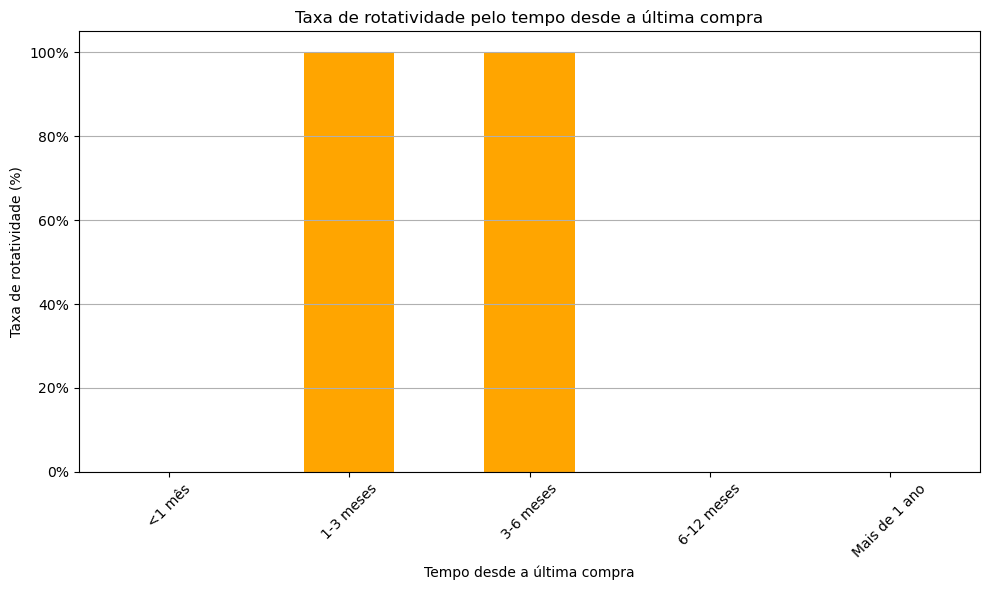

In [89]:
# Agrupando o tempo desde a última compra com a rotatividade
recency_churn = id_merged.groupby('recency_category')['churn'].agg(['mean', 'count'])

# Renomeando a média
recency_churn.rename(columns={'mean': 'churn_rate'}, inplace=True)

plt.figure(figsize=(10,6))
recency_churn['churn_rate'].plot(kind='bar', color='orange')
plt.title('Taxa de rotatividade pelo tempo desde a última compra')
plt.xlabel('Tempo desde a última compra')
plt.ylabel('Taxa de rotatividade (%)')
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.grid(axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




<span style="color: black; font-family: Arial; font-size: 20px;">
Clientes que fizeram sua última compra entre 1 a 6 meses tem uma tendência maior a sair da empresa.




## Teste de hipóteses

<span style="color: blue; font-family: Arial; font-size: 20px;">
Teste: Clientes que geram um crescimento de receita abaixo da média são mais propensos a sair.

In [93]:
# H₀: Clientes que geram um crescimento de receita abaixo da média não são mais propensos a sair
# H₁: Clientes que geram um crescimento de receita abaixo da média são mais propensos a sair

In [94]:
# Apenas clientes que possuem 'end_date' conhecida
df_test = id_merged[id_merged['total_charges'].notna()]

group_churned = df_test[df_test['churn'] == True]['total_charges']
group_retained = df_test[df_test['churn'] == False]['total_charges']

stat_levene, p_levene = levene(group_churned, group_retained)
equal_var = p_levene > 0.05
print(f'Teste de Levene - Estatística: {stat_levene:.4f}, p-valor: {p_levene:.4f}')

Teste de Levene - Estatística: 249.7567, p-valor: 0.0000





<span style="color: black; font-family: Arial; font-size: 20px;">
O teste de Levene indica que as variâncias são diferentes (p-valor < 0.05), então o correto é usar 'equal_var=False' no teste T.



In [96]:
# Apenas clientes que possuem 'end_date' conhecida
df_test = id_merged[id_merged['total_charges'].notna()]

group_churned = df_test[df_test['churn'] == True]['total_charges']
group_retained = df_test[df_test['churn'] == False]['total_charges']

t_stat1, pval1 = ttest_ind(group_churned, group_retained, equal_var=False)

print(f'Teste T - Estatística: {t_stat1:.4f}, p-valor: {pval1:.4f}')
print("A diferença entre os grupos é estatisticamente significativa"
      if pval1 < 0.05 else "Sem diferença significativa")

Teste T - Estatística: -27.1102, p-valor: 0.0000
A diferença entre os grupos é estatisticamente significativa








<span style="color: black; font-family: Arial; font-size: 20px;">
Com base no resultado (p-valor < 0.05), deve-se rejeitar a hipótese nula e considerar que clientes que geram um crescimento abaixo da média são mais propensos a sair.







<span style="color: blue; font-family: Arial; font-size: 20px;">
Teste: Clientes cuja última compra foi há muito tempo estão mais propensos a sair.

In [99]:
# H₀: Clientes cuja última compra foi há muito tempo não estão mais propensos a sair.
# H₁: Clientes cuja última compra foi há muito tempo estão mais propensos a sair.

In [100]:
# Apenas clientes que possuem 'days_since_last_purchase' conhecido
df_test = id_merged[id_merged['days_since_last_purchase'].notna()].copy()

group_churned1 = df_test[df_test['churn'] == True]['days_since_last_purchase']
group_retained1 = df_test[df_test['churn'] == False]['days_since_last_purchase']

stat_levene, p_levene = levene(group_churned1, group_retained1)
equal_var = p_levene > 0.05
print(f'Teste de Levene - Estatística: {stat_levene:.4f}, p-valor: {p_levene:.4f}')

Teste de Levene - Estatística: 6217.3127, p-valor: 0.0000


<span style="color: black; font-family: Arial; font-size: 20px;">
O teste de Levene indica que as variâncias são diferentes (p-valor < 0.05), então o correto é usar 'equal_var=False' no teste T.

In [102]:
# Apenas clientes que possuem 'days_since_last_purchase' conhecido
df_test = id_merged[id_merged['days_since_last_purchase'].notna()].copy()

group_churned1 = df_test[df_test['churn'] == True]['days_since_last_purchase']
group_retained1 = df_test[df_test['churn'] == False]['days_since_last_purchase']

t_stat1, pval1 = ttest_ind(group_churned1, group_retained1, equal_var=False)

print(f'Teste T - Estatística: {t_stat1:.4f}, p-valor: {pval1:.4f}')
print("A diferença entre os grupos é estatisticamente significativa"
      if pval1 < 0.05 else "Sem diferença significativa")

Teste T - Estatística: 91.2211, p-valor: 0.0000
A diferença entre os grupos é estatisticamente significativa





<span style="color: black; font-family: Arial; font-size: 20px;">

Com base no resultado (p-valor < 0.05), deve-se rejeitar a hipótese nula e considerar que clientes cuja última compra foi há muito tempo estão mais propensos a sair.




## Conclusões e recomendações

<span style="color: black; font-family: Arial; font-size: 20px;">
A análise realizada permitiu identificar padrões consistentes entre os clientes que permanecem na Interconnect e aqueles que cancelam seus contratos. Pôde-se observar que clientes com maior engajamento financeiro e relacionamento de longo prazo tendem a permanecer mais tempo com a empresa. 

Fatores como crescimento de receita, tempo de permanência, tipo de contrato, última data de compra e o uso de serviços específicos (como internet via DSL) mostraram-se relevantes na retenção de clientes. Por outro lado, a análise também revelou que **clientes idosos**, **sem dependentes ou parceiros**, **com contratos curtos** e **usuários de fibra óptica** apresentaram maior taxa de rotatividade.

Os testes estatísticos confirmaram que:

- Clientes que **saíram da empresa** apresentam **crescimento de receita abaixo da média**;
- Clientes que **estavam há mais tempo sem comprar** também possuem **maior probabilidade de churn**.

Como recomendações para reduzir a rotatividade de clientes, destacam-se

1. **Campanhas de retenção direcionadas** a clientes:
   - Com **baixo crescimento de receita**;
   - Com **menos de 1 ano de contrato ativo**;
   - Que **não realizam compras há mais de 30 dias**.

2. **Incentivos para usuários de fibra óptica**, principalmente nos primeiros meses de contrato, para reduzir a rotatividade nesse grupo.

3. **Promoções e planos que estimulem contratos mais longos**, com recompensas progressivas e fidelização.

4. **Ações específicas para perfis com alto risco**, como:
   - **Clientes idosos sem dependentes/parceiros**;
   - Oferecer suporte personalizado e planos simplificados para esse público.

5. **Reativação de clientes inativos**:
   - Monitorar a **tempo desde que o cliente fez a última compra**.

6. **Valorização da fidelidade**:
   - Clientes com mais de **3 anos de relacionamento** têm taxas de rotatividade significativamente menores. Recompensas e reconhecimentos podem ajudar a manter esse público fiel.